# LOGISTICS MODEL - MULTI CLASS

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors
import re
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

In [102]:
df = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/HomeCredit_columns_description.xlsx")

In [103]:
df.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [104]:
try:
    app_train = pd.read_csv('application_train.csv')
    app_test = pd.read_csv('application_test.csv')
except FileNotFoundError:
    print("Data files not found. Using sample data for demonstration.")

    np.random.seed(42)
    sample_size = 1000
    
    app_train = pd.DataFrame({
        'SK_ID_CURR': range(1000, 1000+sample_size),
        'TARGET': np.random.randint(0, 2, size=sample_size),
        'NAME_CONTRACT_TYPE': np.random.choice(['Cash loans', 'Revolving loans'], size=sample_size),
        'CODE_GENDER': np.random.choice(['M', 'F', 'XNA'], size=sample_size, p=[0.5, 0.49, 0.01]),
        'FLAG_OWN_CAR': np.random.choice(['Y', 'N'], size=sample_size),
        'FLAG_OWN_REALTY': np.random.choice(['Y', 'N'], size=sample_size),
        'CNT_CHILDREN': np.random.poisson(0.5, size=sample_size),
        'AMT_INCOME_TOTAL': np.random.lognormal(10, 0.5, size=sample_size),
        'AMT_CREDIT': np.random.lognormal(11, 0.4, size=sample_size),
        'AMT_ANNUITY': np.random.lognormal(9, 0.3, size=sample_size),
        'AMT_GOODS_PRICE': np.random.lognormal(10.5, 0.4, size=sample_size),
        'NAME_INCOME_TYPE': np.random.choice(['Working', 'Commercial associate', 'Pensioner', 'State servant'], 
                                            size=sample_size),
        'NAME_EDUCATION_TYPE': np.random.choice(['Secondary', 'Higher education', 'Incomplete higher', 
                                                'Lower secondary', 'Academic degree'], size=sample_size),
        'DAYS_BIRTH': -np.random.randint(18*365, 70*365, size=sample_size),
        'DAYS_EMPLOYED': np.random.choice([-np.random.randint(0, 40*365), 365243], 
                                        size=sample_size, p=[0.95, 0.05]),
        'EXT_SOURCE_2': np.random.uniform(0, 1, size=sample_size),
        'EXT_SOURCE_3': np.random.uniform(0, 1, size=sample_size)
    })
    
    app_test = app_train.sample(200).drop('TARGET', axis=1)

print("Training data shape:", app_train.shape)
app_train.head()

Data files not found. Using sample data for demonstration.
Training data shape: (1000, 17)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3
0,1000,0,Revolving loans,M,N,Y,1,19950.931950,34367.017156,11334.310142,31706.453676,State servant,Secondary,-24604,-13149,0.877027,0.110021
1,1001,1,Cash loans,F,Y,Y,0,61941.964493,81270.968493,8134.853512,35719.967248,State servant,Academic degree,-25215,-13149,0.180973,0.559841
2,1002,0,Cash loans,F,Y,Y,1,8814.548521,58615.666094,7678.847059,36601.329601,State servant,Lower secondary,-10459,365243,0.797259,0.246916
3,1003,0,Cash loans,F,Y,Y,2,13021.342801,48031.257630,7840.033219,26344.847237,Commercial associate,Incomplete higher,-7896,-13149,0.456980,0.977145
4,1004,0,Cash loans,F,N,N,1,46570.186542,64036.347845,11939.626443,45778.574704,Working,Secondary,-12471,-13149,0.328272,0.796581


In [105]:
app_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1499.500000,0.51000,0.474000,24285.068181,64036.557433,8411.701837,39469.522380,-16001.931000,10689.696000,0.491475,0.504458
std,288.819436,0.50015,0.697001,12757.102845,26507.194069,2648.640067,17606.610914,5461.648207,91981.242538,0.290363,0.296478
min,1000.000000,0.00000,0.000000,4896.048989,16803.096682,3395.294685,10012.538711,-25538.000000,-13149.000000,0.001334,0.001725
25%,1249.750000,0.00000,0.000000,15236.575547,46022.438406,6525.575624,26925.303197,-20945.750000,-13149.000000,0.235251,0.241285
50%,1499.500000,1.00000,0.000000,21795.570219,59375.617545,7993.008775,35852.982163,-15662.000000,-13149.000000,0.481333,0.497281
75%,1749.250000,1.00000,1.000000,29633.160200,77724.428287,9946.461407,48054.580939,-11328.000000,-13149.000000,0.739979,0.773579
max,1999.000000,1.00000,4.000000,111473.980599,207973.111859,20526.865723,148988.153496,-6586.000000,365243.000000,0.998845,0.997696


In [106]:
app_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SK_ID_CURR           1000 non-null   int64  
 1   TARGET               1000 non-null   int64  
 2   NAME_CONTRACT_TYPE   1000 non-null   object 
 3   CODE_GENDER          1000 non-null   object 
 4   FLAG_OWN_CAR         1000 non-null   object 
 5   FLAG_OWN_REALTY      1000 non-null   object 
 6   CNT_CHILDREN         1000 non-null   int64  
 7   AMT_INCOME_TOTAL     1000 non-null   float64
 8   AMT_CREDIT           1000 non-null   float64
 9   AMT_ANNUITY          1000 non-null   float64
 10  AMT_GOODS_PRICE      1000 non-null   float64
 11  NAME_INCOME_TYPE     1000 non-null   object 
 12  NAME_EDUCATION_TYPE  1000 non-null   object 
 13  DAYS_BIRTH           1000 non-null   int64  
 14  DAYS_EMPLOYED        1000 non-null   int64  
 15  EXT_SOURCE_2         1000 non-null   fl

In [107]:
print(app_train.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2',
       'EXT_SOURCE_3'],
      dtype='object')


In [108]:
print(app_train.dtypes[app_train.dtypes == 'object'])

NAME_CONTRACT_TYPE     object
CODE_GENDER            object
FLAG_OWN_CAR           object
FLAG_OWN_REALTY        object
NAME_INCOME_TYPE       object
NAME_EDUCATION_TYPE    object
dtype: object


In [109]:
df_encoded = pd.get_dummies(app_train, dtype='float64')
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SK_ID_CURR                             1000 non-null   int64  
 1   TARGET                                 1000 non-null   int64  
 2   CNT_CHILDREN                           1000 non-null   int64  
 3   AMT_INCOME_TOTAL                       1000 non-null   float64
 4   AMT_CREDIT                             1000 non-null   float64
 5   AMT_ANNUITY                            1000 non-null   float64
 6   AMT_GOODS_PRICE                        1000 non-null   float64
 7   DAYS_BIRTH                             1000 non-null   int64  
 8   DAYS_EMPLOYED                          1000 non-null   int64  
 9   EXT_SOURCE_2                           1000 non-null   float64
 10  EXT_SOURCE_3                           1000 non-null   float64
 11  NAME_

In [110]:
print(df_encoded.columns)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'NAME_CONTRACT_TYPE_Cash loans', 'NAME_CONTRACT_TYPE_Revolving loans',
       'CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_N',
       'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y',
       'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working',
       'NAME_EDUCATION_TYPE_Academic degree',
       'NAME_EDUCATION_TYPE_Higher education',
       'NAME_EDUCATION_TYPE_Incomplete higher',
       'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary'],
      dtype='object')


In [111]:
columns_to_drop = ['NAME_CONTRACT_TYPE_Cash loans', 'NAME_CONTRACT_TYPE_Revolving loans',
       'CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_N',
       'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y',
       'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working',
       'NAME_EDUCATION_TYPE_Academic degree',
       'NAME_EDUCATION_TYPE_Higher education',
       'NAME_EDUCATION_TYPE_Incomplete higher',
       'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary']

df_encoded = df_encoded.drop(columns=columns_to_drop)

In [112]:
df_encoded.info()
#'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL','AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE','NAME_EDUCATION_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2','EXT_SOURCE_3'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SK_ID_CURR        1000 non-null   int64  
 1   TARGET            1000 non-null   int64  
 2   CNT_CHILDREN      1000 non-null   int64  
 3   AMT_INCOME_TOTAL  1000 non-null   float64
 4   AMT_CREDIT        1000 non-null   float64
 5   AMT_ANNUITY       1000 non-null   float64
 6   AMT_GOODS_PRICE   1000 non-null   float64
 7   DAYS_BIRTH        1000 non-null   int64  
 8   DAYS_EMPLOYED     1000 non-null   int64  
 9   EXT_SOURCE_2      1000 non-null   float64
 10  EXT_SOURCE_3      1000 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 86.1 KB


In [113]:
print(df_encoded.columns.tolist())

['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


In [114]:
selected_cols = ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
df_model = df_encoded[selected_cols + ['AMT_INCOME_TOTAL']].dropna()
X = df_model[selected_cols]
y = df_model['AMT_INCOME_TOTAL']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [115]:
df_encoded.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3
0,1000,0,1,19950.931950,34367.017156,11334.310142,31706.453676,-24604,-13149,0.877027,0.110021
1,1001,1,0,61941.964493,81270.968493,8134.853512,35719.967248,-25215,-13149,0.180973,0.559841
2,1002,0,1,8814.548521,58615.666094,7678.847059,36601.329601,-10459,365243,0.797259,0.246916
3,1003,0,2,13021.342801,48031.257630,7840.033219,26344.847237,-7896,-13149,0.456980,0.977145
4,1004,0,1,46570.186542,64036.347845,11939.626443,45778.574704,-12471,-13149,0.328272,0.796581


In [116]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

predictions = lin_reg.predict(X_test)

print("Intercept:",lin_reg.intercept_)
print("Coefficients:",lin_reg.coef_)

Intercept: 21124.587486071454
Coefficients: [0.00118978 0.31491687 0.00826196]


In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [119]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [123]:
df_encoded1 = df_encoded[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED']].dropna()

In [121]:
df_encoded1['INCOME_GROUP'] = pd.qcut(df_encoded1['AMT_INCOME_TOTAL'], q=3, labels=[0, 1, 2])

In [124]:
X = df_encoded1[['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED']]
y = df_encoded1['INCOME_GROUP']

KeyError: 'INCOME_GROUP'

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial')

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           INCOME_GROUP   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.519
Date:                Wed, 04 Jun 2025   Prob (F-statistic):              0.208
Time:                        14:56:26   Log-Likelihood:                -1214.9
No. Observations:                1000   AIC:                             2438.
Df Residuals:                     996   BIC:                             2457.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.8271      0.120     

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# create pipeline - xử lý dữ liệu
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # replace missing values by median
    ('scaler', StandardScaler())  # chuẩn hoá
])

X_processed = preprocessor.fit_transform(X)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Tính trọng số cho từng lớp
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Đưa vào model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, class_weight=class_weight_dict)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight={0: 0.9929078014184397, 1: 1.0014306151645207,
                                 2: 1.0057471264367817},
                   max_iter=500, multi_class='multinomial')

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.52      0.41        99
           1       0.41      0.23      0.30        99
           2       0.34      0.32      0.33       102

    accuracy                           0.36       300
   macro avg       0.37      0.36      0.35       300
weighted avg       0.37      0.36      0.35       300

Confusion Matrix:
[[51 15 33]
 [45 23 31]
 [51 18 33]]


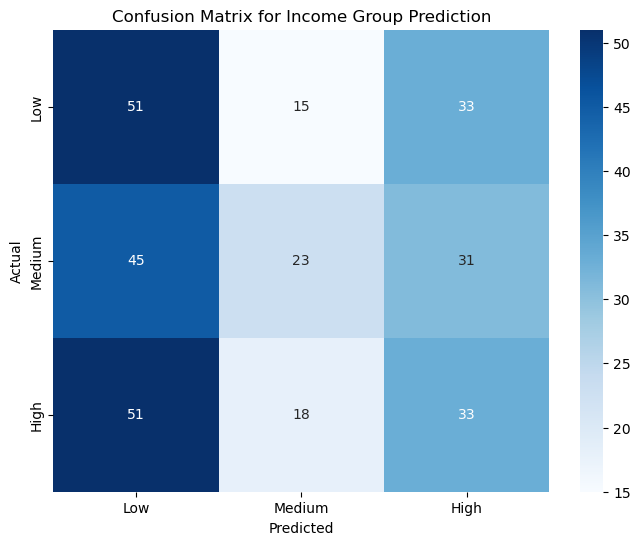

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix for Income Group Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

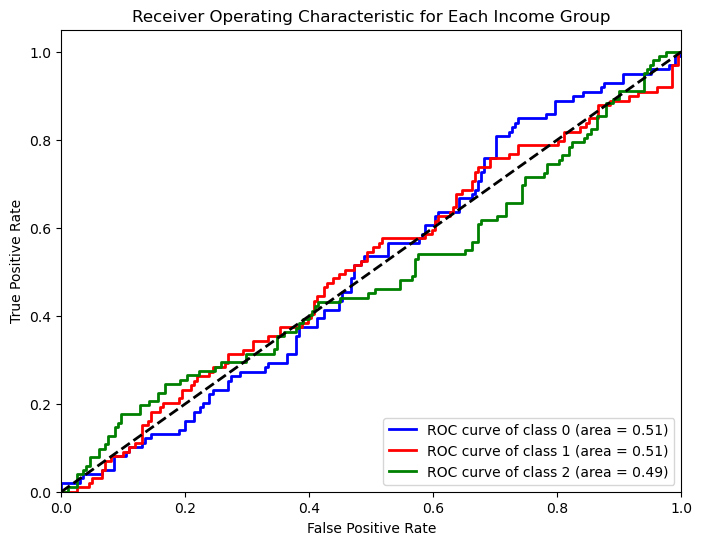

In [ ]:
plt.figure(figsize=(8, 6))
n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Each Income Group')
plt.legend(loc="lower right")
plt.show()

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


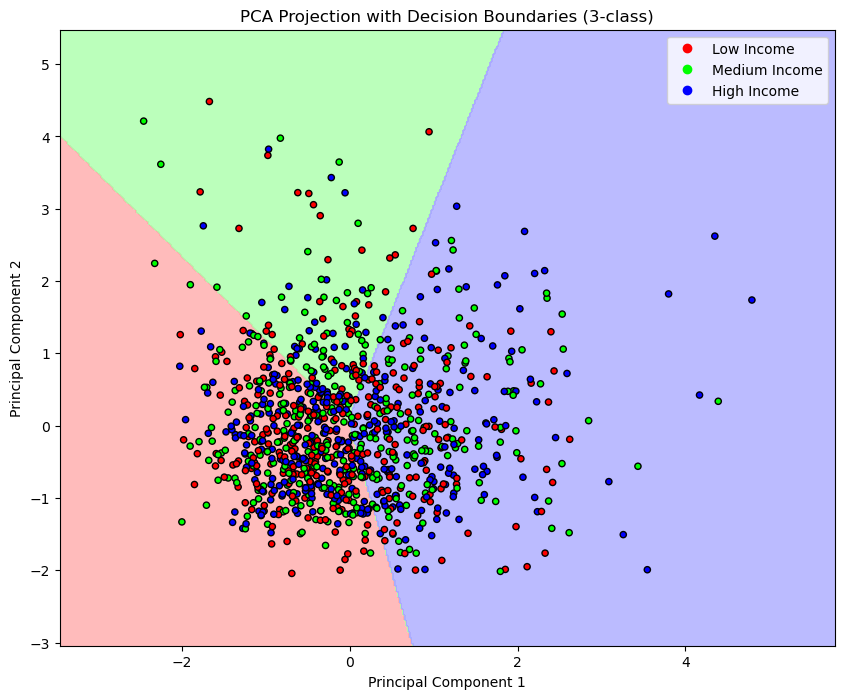

In [ ]:
model_pca = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
model_pca.fit(X_pca, y)

h = .02  
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=cmap_bold,
                      edgecolor='k', s=20)
plt.title("PCA Projection with Decision Boundaries (3-class)")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], 
           labels=['Low Income', 'Medium Income', 'High Income'])
plt.show()
